In [ ]:
!pip install ultralytics opencv-python-headless deep-sort-realtime pandas matplotlib seaborn tensorflow

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
from google.colab import files
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

Saving mall.mp4 to mall.mp4


In [ ]:
model = YOLO("yolov8n.pt")  # lightweight model
tracker = DeepSort(max_age=30)

In [ ]:
cap = cv2.VideoCapture(video_path)

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter('output.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps,
                      (frame_width, frame_height))

frame_area = frame_width * frame_height

data = []
frame_id = 0

heatmap_accumulator = np.zeros((frame_height, frame_width))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)[0]

    detections = []
    person_count = 0

    for box in results.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        if cls == 0 and conf > 0.4:  # person class
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            detections.append(([x1, y1, x2-x1, y2-y1], conf, 'person'))

    tracks = tracker.update_tracks(detections, frame=frame)

    person_ids = set()

    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        l, t, w, h = map(int, track.to_ltrb())

        person_ids.add(track_id)

        # Draw box
        cv2.rectangle(frame, (l, t), (l+w, t+h), (0,255,0), 2)
        cv2.putText(frame, f"ID {track_id}", (l, t-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

        # Heatmap accumulation
        heatmap_accumulator[t:t+h, l:l+w] += 1

    person_count = len(person_ids)
    density = person_count / frame_area

    timestamp = frame_id / fps

    data.append([frame_id, timestamp, person_count, density])

    # Overlay count
    cv2.putText(frame, f"Count: {person_count}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    cv2.putText(frame, f"Density: {density:.6f}", (20,80),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

    out.write(frame)
    frame_id += 1

cap.release()
out.release()


0: 384x640 9 persons, 2 handbags, 2 suitcases, 417.5ms
Speed: 10.2ms preprocess, 417.5ms inference, 38.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 handbag, 2 suitcases, 292.3ms
Speed: 4.0ms preprocess, 292.3ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 handbag, 1 suitcase, 475.6ms
Speed: 9.9ms preprocess, 475.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 2 suitcases, 231.6ms
Speed: 5.4ms preprocess, 231.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 1 backpack, 231.4ms
Speed: 9.2ms preprocess, 231.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 persons, 1 backpack, 232.4ms
Speed: 5.0ms preprocess, 232.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 persons, 1 suitcase, 153.7ms
Speed: 5.9ms preprocess, 153.7ms inference, 1.0ms postprocess per imag

In [ ]:
df = pd.DataFrame(data, columns=["frame", "timestamp", "count", "density"])
df.to_csv("crowd_data.csv", index=False)

df.head()

,frame,timestamp,count,density
0,0,0.000000,0,0.000000
1,1,0.034483,0,0.000000
2,2,0.068966,6,0.000015
3,3,0.103448,7,0.000017
4,4,0.137931,7,0.000017


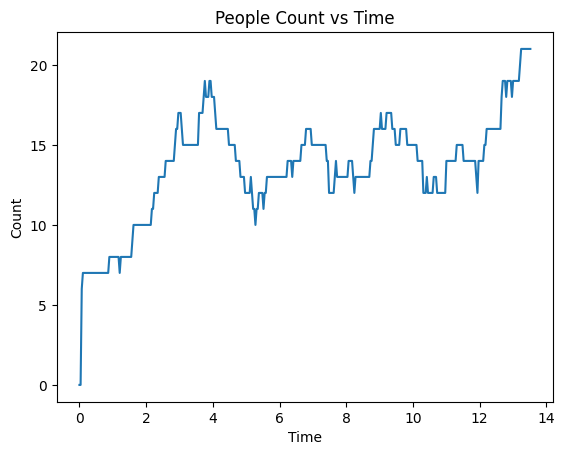

In [ ]:
plt.figure()
plt.plot(df["timestamp"], df["count"])
plt.title("People Count vs Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
counts_scaled = scaler.fit_transform(df["count"].values.reshape(-1,1))

X = []
y = []
window = 10

for i in range(len(counts_scaled) - window):
    X.append(counts_scaled[i:i+window])
    y.append(counts_scaled[i+window])

X, y = np.array(X), np.array(y)

In [ ]:
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(window,1)),
    LSTM(50),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X, y, epochs=10, batch_size=16)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0909
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0069
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0035
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0029
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0026
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0027
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0024


In [ ]:
predictions = model_lstm.predict(X)
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


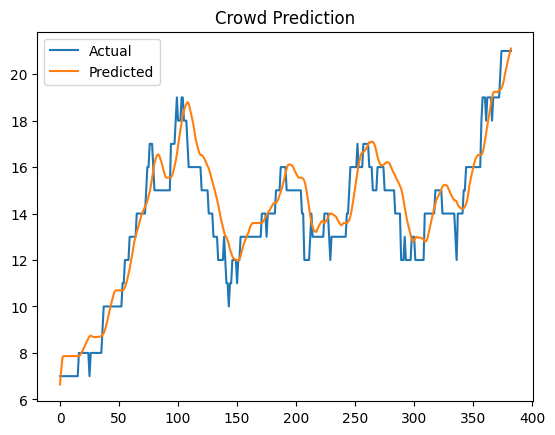

In [ ]:
plt.figure()
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Crowd Prediction")
plt.show()

In [ ]:
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install ultralytics opencv-python

import cv2
import os
from ultralytics import YOLO
from google.colab import files

# Upload video
uploaded = files.upload()

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

video_path = "mall.mp4"  # change if your file name is different

# Output folder for images
output_folder = "output_frames"
os.makedirs(output_folder, exist_ok=True)

# Open video
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("❌ Cannot open video")
    exit()

fps = int(cap.get(cv2.CAP_PROP_FPS))
fps = fps if fps > 0 else 30

frame_count = 0
saved_count = 0

# List to store frame info
frame_data = []  # Each item: [frame_number, people_count, frame_area]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Extract 1 frame per second
    if frame_count % fps == 0:

        # Frame area (height * width)
        height, width = frame.shape[:2]
        area = height * width

        # YOLO detection
        results = model(frame)
        person_count = 0

        for r in results:
            for box in r.boxes:
                cls = int(box.cls[0])
                if cls == 0:  # person
                    person_count += 1
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw people count on frame
        cv2.putText(frame, f"People: {person_count}",
                    (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        # Save frame
        filename = f"{output_folder}/frame_{saved_count}.jpg"
        cv2.imwrite(filename, frame)

        # Add info to Python list
        frame_data.append([saved_count, person_count, area])

        saved_count += 1

    frame_count += 1

cap.release()
print("🎉 Done! Frames processed:", saved_count)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving mall.mp4 to mall.mp4

0: 384x640 9 persons, 2 handbags, 2 suitcases, 403.4ms
Speed: 16.0ms preprocess, 403.4ms inference, 48.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 2 handbags, 2 suitcases, 168.0ms
Speed: 5.4ms preprocess, 168.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 1 handbag, 1 suitcase, 153.1ms
Speed: 3.7ms preprocess, 153.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 persons, 1 suitcase, 152.0ms
Speed: 3.2ms preprocess, 152.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 146.5ms
Speed: 2.9ms preprocess, 146.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 166.2ms
Speed: 2.9ms preprocess, 166.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 1 suitcase, 151.2ms
Speed: 3.9ms preprocess, 151.2ms inference, 1.5ms postprocess p

In [ ]:
# Display all frames info
print("Frame_No | People_Count | Frame_Area")
for item in frame_data:
    print(item)

Frame_No | People_Count | Frame_Area
[0, 9, 405344]
[1, 10, 405344]
[2, 10, 405344]
[3, 14, 405344]
[4, 11, 405344]
[5, 9, 405344]
[6, 11, 405344]
[7, 10, 405344]
[8, 13, 405344]
[9, 14, 405344]
[10, 10, 405344]
[11, 10, 405344]
[12, 11, 405344]
[13, 13, 405344]
